# Notebook 07 — Q3.4 Cross-Method Comparison

**Stage 3 / Q3.4** · Python 3.11 (`melanoma-scrnaseq` env)

Cross-method comparison between **Harmony** (linear post-PCA correction,
Stage 2 baseline) and **BBKNN** (graph-based batch correction, Q3.2) on
the 1,257 Tirosh malignant cells. Self-contained and re-runnable.

## Method scope

Per the Stage 3 Working Spec (`CLAUDE.md`) and decision log
(`docs/decision_log.md` entries b / d / f), Stage 3 settled on a
**two-method** comparison after four other candidates were investigated
and ruled out:

- **Method 1 — Harmony** at `leiden_r0.3` (6 clusters, Stage 2 working resolution)
- **Method 2 — BBKNN** at `leiden_bbknn_r0.5` (3 clusters, Q3.2 working resolution)
- *Ruled out:* scVI / scANVI (raw-count, entry a), UCE (raw-count + GPU, b), Seurat RPCA (R/Python interop, c), Scanorama (small-batch failure, d), scGen (API drift + abandonment, f).

## Inputs / outputs

| Input | Description |
|---|---|
| `data/processed/tirosh_malignant_annotated.h5ad` | Stage 2 Harmony output + `tsoi_state` |
| `data/processed/tirosh_malignant_bbknn.h5ad`     | Q3.2 BBKNN output + `tsoi_state_bbknn` |

| Output | Description |
|---|---|
| inline cell outputs | A1 / A2 / B1 / B2 / C1 / C2 numbers + crosstabs |
| `results/figures/07_combined_dotplot.png` | Visual 1 — combined marker dotplot |
| `results/figures/07_method_comparison_umap_grid.png` | Visual 2 — 2×2 UMAP grid |


## Phase 0 + 1 — setup, sanity check, build `comp` AnnData

Load the two h5ad inputs, verify they're aligned (identical `obs_names`,
same row order), and merge BBKNN's per-cluster annotations and embedding
into a single `comp` object using the Harmony adata as the base. Note:
`obs['patient']` and `obs['tumor_id']` are a verified bijection over the
15 malignant patients; we use `tumor_id` throughout.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors

%matplotlib inline

# Repo root resolution: tolerate running from notebooks/ OR repo root
REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
FIGDIR = REPO / "results/figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# Publication-quality matplotlib defaults (applies to all subsequent cells)
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "savefig.dpi": 300,
})

# --- Phase 0: load + verify alignment ----------------------------------
ah = sc.read_h5ad(REPO / "data/processed/tirosh_malignant_annotated.h5ad")
ab = sc.read_h5ad(REPO / "data/processed/tirosh_malignant_bbknn.h5ad")
assert list(ah.obs_names) == list(ab.obs_names), "obs_names row order diverged"

# --- Phase 1: merge BBKNN annotations + embedding + graph into comp ----
comp = ah.copy()
comp.obs["leiden_bbknn_r0.5"] = ab.obs["leiden_bbknn_r0.5"].values
comp.obs["tsoi_state_bbknn"]  = ab.obs["tsoi_state_bbknn"].values
comp.obsm["X_umap_bbknn"]     = ab.obsm["X_umap_bbknn"]
if "connectivities" in ab.obsp:
    comp.obsp["bbknn_connectivities"] = ab.obsp["connectivities"]
if "distances" in ab.obsp:
    comp.obsp["bbknn_distances"] = ab.obsp["distances"]

print(f"comp.shape       : {comp.shape}    (expect (1257, 23686))")
print(f"comp.obs columns : {list(comp.obs.columns)}")
print(f"comp.obsm keys   : {list(comp.obsm.keys())}")
print(f"comp.obsp keys   : {list(comp.obsp.keys())}")


comp.shape       : (1257, 23686)    (expect (1257, 23686))
comp.obs columns : ['tumor_id', 'malignant_status', 'cell_type_code', 'malignant_label', 'cell_type_label', 'patient', 'n_genes_by_counts', 'total_counts', 'leiden_r0.1', 'leiden_r0.2', 'leiden_r0.3', 'leiden_r0.5', 'leiden_r0.8', 'leiden_r1.0', 'tsoi_state', 'leiden_bbknn_r0.5', 'tsoi_state_bbknn']
comp.obsm keys   : ['X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_uncorrected', 'X_umap_bbknn']
comp.obsp keys   : ['connectivities', 'distances', 'bbknn_connectivities', 'bbknn_distances']


## Phase 2 — Metric A: batch integration quality

**A1 — patient silhouette** on each method's own 2-D UMAP (lower = better
mixing). Q3.4-internal convention: 2-D UMAP, full 1 257 cells, label =
`tumor_id`, sklearn defaults (Euclidean, no subsampling, deterministic).

**A2 — kNN patient purity** in each method's native integration output:
Harmony on 30-D `X_pca_harmony[:, :30]`, k = 15; BBKNN on the saved
kNN graph (see Algorithmic note below — the BBKNN value is a
hyperparameter artefact, not an integration-quality measure).


In [2]:
labels = comp.obs["tumor_id"].astype(str).values

# --- A1: patient silhouette on 2D UMAP (lower = better mixing) ---------
s_har = silhouette_score(comp.obsm["X_umap"],             labels)
s_bb  = silhouette_score(comp.obsm["X_umap_bbknn"],       labels)
s_raw = silhouette_score(comp.obsm["X_umap_uncorrected"], labels)
print("A1 — patient silhouette on 2D UMAP (lower = better mixing)")
print(f"  Harmony  : {s_har:+.4f}")
print(f"  BBKNN    : {s_bb:+.4f}")
print(f"  Baseline : {s_raw:+.4f}   (X_umap_uncorrected)")
print(f"  Δ Harmony vs baseline = {s_har - s_raw:+.4f}")
print(f"  Δ BBKNN   vs baseline = {s_bb  - s_raw:+.4f}")

# --- A2 Harmony: k=15 kNN on 30D X_pca_harmony -------------------------
X30 = comp.obsm["X_pca_harmony"][:, :30]
nn = NearestNeighbors(n_neighbors=16).fit(X30)
_, idx_h = nn.kneighbors(X30)
idx_h = idx_h[:, 1:]
pur_h = np.array([(labels[nb] == labels[i]).mean() for i, nb in enumerate(idx_h)])

# --- A2 BBKNN: on saved BBKNN graph (distances) ------------------------
G = comp.obsp.get("bbknn_distances")
if G is None:
    G = comp.obsp.get("bbknn_connectivities")
G = G.tocsr()
pur_b = np.zeros(G.shape[0])
nn_counts = np.zeros(G.shape[0], dtype=int)
for i in range(G.shape[0]):
    nb = G.indices[G.indptr[i]:G.indptr[i+1]]
    nb = nb[nb != i]
    nn_counts[i] = len(nb)
    pur_b[i] = (labels[nb] == labels[i]).mean() if len(nb) else np.nan

print()
print("A2 — kNN patient purity (lower = better mixing)")
print(f"  Harmony k=15 on X_pca_harmony[:, :30] : mean = {pur_h.mean():.4f}  std = {pur_h.std():.4f}  median = {np.median(pur_h):.4f}")
print(f"  BBKNN    on saved BBKNN graph         : mean = {pur_b[~np.isnan(pur_b)].mean():.4f}  std = {pur_b[~np.isnan(pur_b)].std():.4f}")
print(f"    effective k per cell: mean={nn_counts.mean():.1f}  range={nn_counts.min()}-{nn_counts.max()}")


A1 — patient silhouette on 2D UMAP (lower = better mixing)
  Harmony  : +0.2564
  BBKNN    : -0.0312
  Baseline : +0.5780   (X_umap_uncorrected)
  Δ Harmony vs baseline = -0.3215
  Δ BBKNN   vs baseline = -0.6091



A2 — kNN patient purity (lower = better mixing)
  Harmony k=15 on X_pca_harmony[:, :30] : mean = 0.7321  std = 0.3342  median = 0.9333
  BBKNN    on saved BBKNN graph         : mean = 0.0455  std = 0.0000
    effective k per cell: mean=44.0  range=44-44


### Algorithmic note — A2 on the BBKNN graph

A2 cannot be meaningfully computed on the saved BBKNN k-NN graph.
BBKNN constructs `neighbors_within_batch = 3` neighbours per patient × 15
patients = 45 neighbours per cell (44 after self-exclusion), of which
exactly 2 are from the same patient. The per-cell purity is therefore
**2 / 44 = 0.0455 for every cell, with zero variance**, regardless of
integration quality. The value above is reported as a methodological
observation about BBKNN's algorithm — not as an integration-quality
comparator.


## Phase 3 — Metric B: biological signal preservation

**B1** — per-cluster marker statistics for both methods, 4 Tsoi markers
(MITF / SOX10 / NGFR / AXL). Output: `mean` = mean log2(TPM/10+1) ;
`pct` = % cells with X > 0.

**B2** — Tsoi-state silhouette on 2-D UMAP (higher = states more
separable). We report 4 numbers: 2 self silhouettes (each method on its
own annotation) and 2 cross silhouettes (each method's UMAP scored
against the OTHER method's annotation). The cross silhouettes surface
the method-level asymmetry.


In [3]:
MARKERS = ["MITF", "SOX10", "NGFR", "AXL"]

def cluster_marker_table(adata, cluster_col, markers):
    X = adata[:, markers].X
    if hasattr(X, "toarray"):
        X = X.toarray()
    X = np.asarray(X, dtype=float)
    df = pd.DataFrame(X, columns=markers, index=adata.obs_names)
    df["cluster"] = adata.obs[cluster_col].astype(str).values
    rows = []
    for clust, g in df.groupby("cluster"):
        row = {"cluster": clust, "n_cells": int(len(g))}
        for m in markers:
            v = g[m].values
            row[f"{m}_mean"] = float(v.mean())
            row[f"{m}_pct"]  = float((v > 0).mean() * 100)
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values("cluster", key=lambda s: s.astype(int))
        .reset_index(drop=True)
    )

print("B1 — marker expression per cluster")
print("  mean = mean log2(TPM/10+1);  pct = % cells with X > 0")

tab_h = cluster_marker_table(comp, "leiden_r0.3", MARKERS)
tab_b = cluster_marker_table(comp, "leiden_bbknn_r0.5", MARKERS)
with pd.option_context("display.max_columns", 30, "display.width", 220,
                       "display.float_format", "{:7.3f}".format):
    print()
    print("--- Harmony @ leiden_r0.3 (6 clusters) ---")
    print(tab_h.to_string(index=False))
    print()
    print("--- BBKNN @ leiden_bbknn_r0.5 (3 clusters) ---")
    print(tab_b.to_string(index=False))

# --- B2: Tsoi-state silhouette on 2D UMAP ------------------------------
lab_h = comp.obs["tsoi_state"].astype(str).values
lab_b = comp.obs["tsoi_state_bbknn"].astype(str).values

self_h = silhouette_score(comp.obsm["X_umap"],       lab_h)
self_b = silhouette_score(comp.obsm["X_umap_bbknn"], lab_b)
cross_h_x_b = silhouette_score(comp.obsm["X_umap"],       lab_b)
cross_b_x_h = silhouette_score(comp.obsm["X_umap_bbknn"], lab_h)

print()
print("B2 — Tsoi-state silhouette on 2D UMAP (higher = better signal)")
print(f"  self  Harmony UMAP × tsoi_state              = {self_h:+.4f}")
print(f"  self  BBKNN   UMAP × tsoi_state_bbknn        = {self_b:+.4f}")
print(f"  cross Harmony UMAP × tsoi_state_bbknn        = {cross_h_x_b:+.4f}")
print(f"  cross BBKNN   UMAP × tsoi_state              = {cross_b_x_h:+.4f}")


B1 — marker expression per cluster
  mean = mean log2(TPM/10+1);  pct = % cells with X > 0



--- Harmony @ leiden_r0.3 (6 clusters) ---
cluster  n_cells  MITF_mean  MITF_pct  SOX10_mean  SOX10_pct  NGFR_mean  NGFR_pct  AXL_mean  AXL_pct
      0      451      4.319    93.570       2.408     86.918      0.109     5.987     0.586   77.384
      1       69      4.077    89.855       2.097     84.058      0.256     7.246     0.715   65.217
      2      179      1.277    54.190       1.617     69.832      0.551    24.581     0.565   69.274
      3      107      3.475    84.112       2.334     85.981      0.830    19.626     0.894   60.748
      4       33      2.351    60.606       2.187     81.818      0.545    21.212     1.621   81.818
      5      418      3.549    88.995       2.408     83.971      0.147     5.263     1.187   71.292

--- BBKNN @ leiden_bbknn_r0.5 (3 clusters) ---
cluster  n_cells  MITF_mean  MITF_pct  SOX10_mean  SOX10_pct  NGFR_mean  NGFR_pct  AXL_mean  AXL_pct
      0      404      4.335    93.564       2.424     87.129      0.144     5.446     0.531   75.000

## Phase 4 — Metric C: cluster recovery + cross-method agreement

**C1** — cluster × Tsoi-state crosstab for each method (100 % pure by
construction; the Stage 2 and Q3.2 annotations were assigned per-cluster).

**C2** — partition agreement (ARI + NMI) at two levels: raw Leiden
labels (6-way vs 3-way) and Tsoi-state labels (strict). The collapsed
variant (catch-alls → `Non-canonical`) is mathematically identical
because ARI / NMI are label-name-invariant — see Limitation L3 in the
conclusions cell.

**Cell-level crosstab** of `tsoi_state` × `tsoi_state_bbknn` — the
key evidence for the Phase 6 "label divergence" finding.


In [4]:
print("C1 — cluster × tsoi_state crosstab")
print()
print("Harmony @ leiden_r0.3:")
ct_h = pd.crosstab(comp.obs["leiden_r0.3"], comp.obs["tsoi_state"])
print(ct_h.to_string())
print()
print("BBKNN @ leiden_bbknn_r0.5:")
ct_b = pd.crosstab(comp.obs["leiden_bbknn_r0.5"], comp.obs["tsoi_state_bbknn"])
print(ct_b.to_string())

# --- C2 -----------------------------------------------------------------
A_leiden = comp.obs["leiden_r0.3"].astype(str).values
B_leiden = comp.obs["leiden_bbknn_r0.5"].astype(str).values
A_state  = comp.obs["tsoi_state"].astype(str).values
B_state  = comp.obs["tsoi_state_bbknn"].astype(str).values

print()
print("C2 — cross-method agreement")
print(f"  Raw Leiden  (6-way vs 3-way)    : ARI = {adjusted_rand_score(A_leiden, B_leiden):+.4f}   NMI = {normalized_mutual_info_score(A_leiden, B_leiden):+.4f}")
print(f"  Tsoi state  (strict)            : ARI = {adjusted_rand_score(A_state,  B_state):+.4f}   NMI = {normalized_mutual_info_score(A_state,  B_state):+.4f}")

# --- Cell-level crosstab (Phase 6 evidence) -----------------------------
ROW_ORDER = ["Melanocytic", "Undifferentiated", "Other (batch?)"]
COL_ORDER = ["Melanocytic", "Undifferentiated", "Ambiguous"]
xt = pd.crosstab(comp.obs["tsoi_state"], comp.obs["tsoi_state_bbknn"]).reindex(
    index=ROW_ORDER, columns=COL_ORDER, fill_value=0
)
xt_m = xt.copy()
xt_m.loc["TOTAL"] = xt.sum(axis=0)
xt_m["TOTAL"]     = xt_m.sum(axis=1)

print()
print("Cell-level crosstab — Harmony tsoi_state (rows) × BBKNN tsoi_state_bbknn (cols)")
print(xt_m.to_string())

print()
print("Harmony 'Other (batch?)' (704 cells) -> BBKNN distribution:")
for col in COL_ORDER:
    n = int(xt.loc["Other (batch?)", col])
    print(f"  -> {col:<20s}: {n:4d} cells  ({n/704*100:5.1f}%)")


C1 — cluster × tsoi_state crosstab

Harmony @ leiden_r0.3:
tsoi_state   Melanocytic  Undifferentiated  Other (batch?)
leiden_r0.3                                               
0                    451                 0               0
1                     69                 0               0
2                      0                 0             179
3                      0                 0             107
4                      0                33               0
5                      0                 0             418

BBKNN @ leiden_bbknn_r0.5:
tsoi_state_bbknn   Melanocytic  Ambiguous  Undifferentiated
leiden_bbknn_r0.5                                          
0                          404          0                 0
1                            0          0               635
2                            0        218                 0

C2 — cross-method agreement
  Raw Leiden  (6-way vs 3-way)    : ARI = +0.4861   NMI = +0.4704
  Tsoi state  (strict)            : ARI = +0.4

## Phase 5 — Killer visuals

Two figures saved to `results/figures/07_*.png` at 300 dpi.

- **Visual 1 — `07_combined_dotplot.png`** — per-cluster marker
  expression, Harmony 6 clusters (top) and BBKNN 3 clusters (bottom)
  vertically stacked, sharing colormap and size scale; size legend
  placed below colorbar in the shared right column.
- **Visual 2 — `07_method_comparison_umap_grid.png`** — 2 × 2 grid:
  top row = Tsoi state per method (locked 4-colour palette: Mel = blue,
  Undiff = red, Other (batch?) = gray, Ambiguous = purple); bottom row
  = patient per method (15-colour `tab20` subset).


saved -> results/figures/07_combined_dotplot.png  (276 KB)


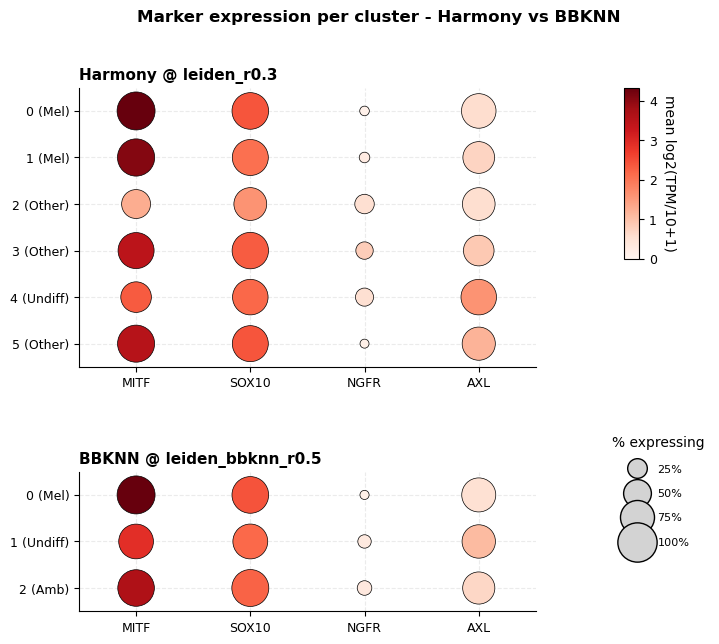

In [5]:
# Visual 1: combined marker dotplot (Harmony 6 clusters + BBKNN 3 clusters)
HARMONY_LABELS = {"0": "0 (Mel)",  "1": "1 (Mel)",    "2": "2 (Other)",
                  "3": "3 (Other)", "4": "4 (Undiff)", "5": "5 (Other)"}
BBKNN_LABELS   = {"0": "0 (Mel)",  "1": "1 (Undiff)", "2": "2 (Amb)"}

def _cluster_stats(adata, cluster_col, markers):
    X = adata[:, markers].X
    if hasattr(X, "toarray"):
        X = X.toarray()
    X = np.asarray(X, dtype=float)
    df = pd.DataFrame(X, columns=markers, index=adata.obs_names)
    df["cluster"] = adata.obs[cluster_col].astype(str).values
    means = df.groupby("cluster")[markers].mean()
    pcts  = df.groupby("cluster")[markers].apply(lambda d: (d > 0).mean() * 100)
    means = means.reindex(sorted(means.index, key=int))
    pcts  = pcts.reindex(sorted(pcts.index, key=int))
    return means, pcts

means_h, pcts_h = _cluster_stats(comp, "leiden_r0.3",       MARKERS)
means_b, pcts_b = _cluster_stats(comp, "leiden_bbknn_r0.5", MARKERS)

V_MIN = 0.0
V_MAX = float(max(means_h.values.max(), means_b.values.max()))
SIZE_FACTOR = 8.0

fig = plt.figure(figsize=(8.0, 6.8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.18], height_ratios=[6, 3],
                      hspace=0.5, wspace=0.30)
ax_h = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0])
right_gs = gs[:, 1].subgridspec(2, 1, height_ratios=[1.0, 1.4], hspace=0.55)
cbar_outer = fig.add_subplot(right_gs[0]); cbar_outer.set_axis_off()
cbar_inner_gs = right_gs[0].subgridspec(1, 3, width_ratios=[0.5, 1, 4], wspace=0.0)
ax_cbar = fig.add_subplot(cbar_inner_gs[0, 1])
ax_size = fig.add_subplot(right_gs[1]); ax_size.set_axis_off()

cmap = plt.cm.Reds

def _plot_dotplot(ax, means, pcts, labels_map, title):
    n_rows, n_cols = means.shape
    xs, ys, cs, ss = [], [], [], []
    for i, clust in enumerate(means.index):
        for j, marker in enumerate(means.columns):
            xs.append(j); ys.append(i)
            cs.append(means.loc[clust, marker])
            ss.append(pcts.loc[clust, marker] * SIZE_FACTOR)
    sct = ax.scatter(xs, ys, c=cs, s=ss, cmap=cmap, vmin=V_MIN, vmax=V_MAX,
                     edgecolors="black", linewidths=0.5)
    ax.set_xticks(range(n_cols)); ax.set_xticklabels(means.columns)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([labels_map.get(c, c) for c in means.index])
    ax.set_xlim(-0.5, n_cols - 0.5); ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontweight="bold")
    ax.grid(True, alpha=0.25, linestyle="--"); ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return sct

m = _plot_dotplot(ax_h, means_h, pcts_h, HARMONY_LABELS, "Harmony @ leiden_r0.3")
_plot_dotplot(ax_b, means_b, pcts_b, BBKNN_LABELS, "BBKNN @ leiden_bbknn_r0.5")

cb = plt.colorbar(m, cax=ax_cbar)
cb.set_label("mean log2(TPM/10+1)", rotation=270, labelpad=14)

legend_pcts = [25, 50, 75, 100]
size_handles = [Line2D([0], [0], marker="o", color="w",
                       markerfacecolor="lightgrey", markeredgecolor="black",
                       markersize=np.sqrt(p * SIZE_FACTOR), label=f"{p}%")
                for p in legend_pcts]
ax_size.legend(handles=size_handles, title="% expressing",
               loc="center", frameon=False, labelspacing=1.3, borderpad=0.5)

fig.suptitle("Marker expression per cluster - Harmony vs BBKNN",
             fontsize=12, fontweight="bold", y=0.995)

out1 = FIGDIR / "07_combined_dotplot.png"
fig.savefig(out1, bbox_inches="tight", dpi=300)
print(f"saved -> {out1.relative_to(REPO)}  ({out1.stat().st_size // 1024} KB)")
plt.show()


saved -> results/figures/07_method_comparison_umap_grid.png  (1485 KB)


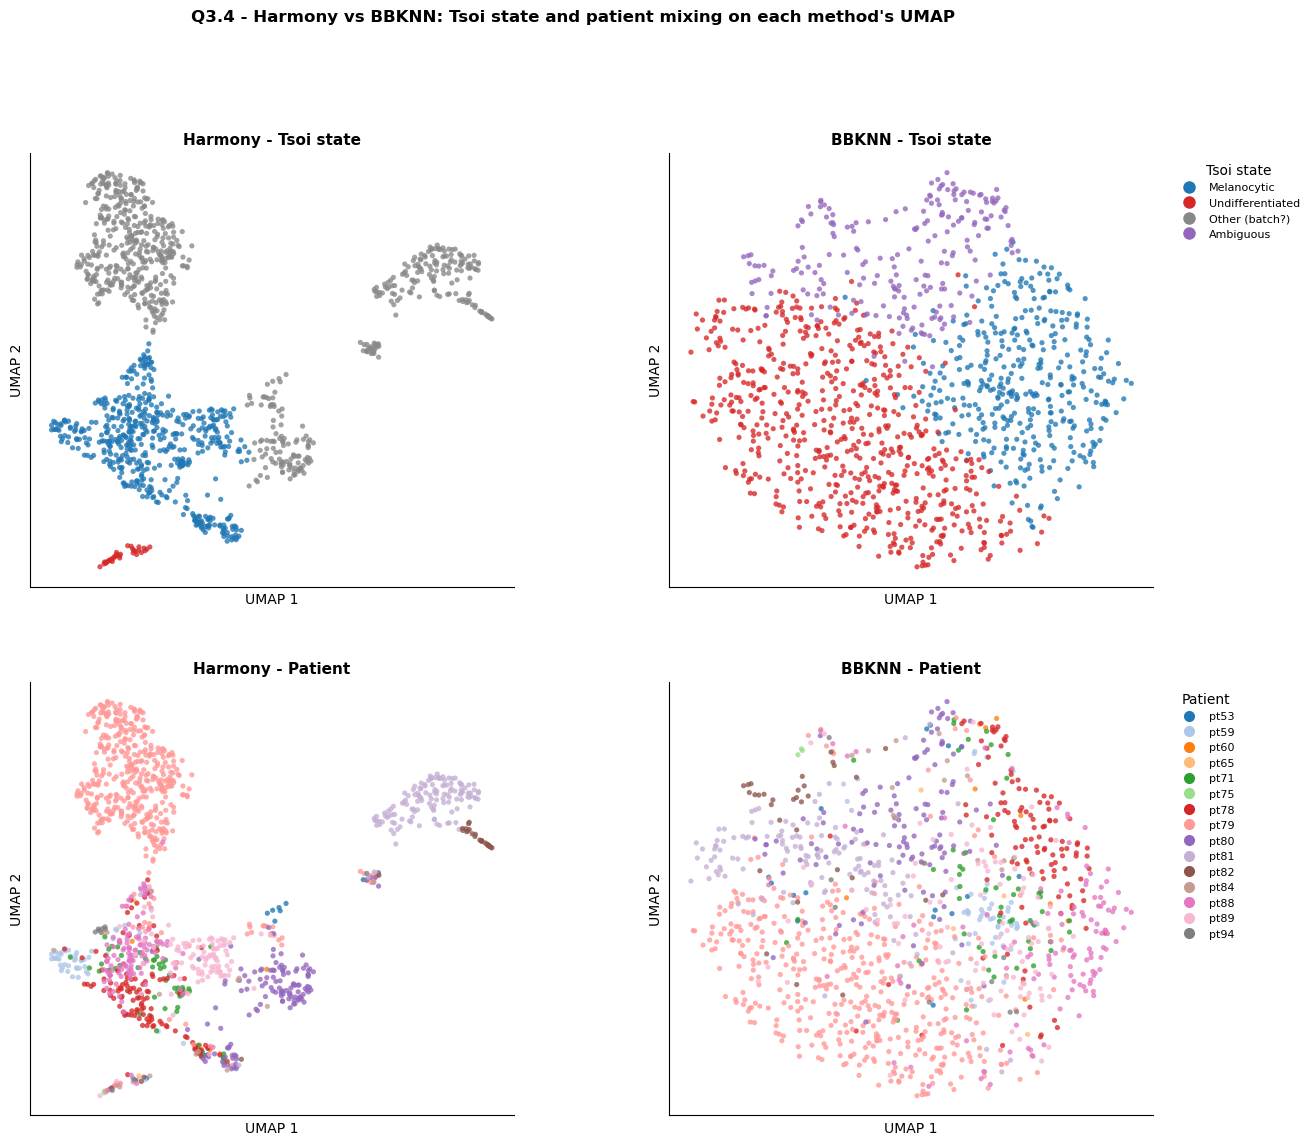

In [6]:
# Visual 2: 2x2 UMAP grid (Tsoi state top row, patient bottom row)
TSOI_COLORS = {
    "Melanocytic":      "#1f77b4",  # blue
    "Undifferentiated": "#d62728",  # red
    "Other (batch?)":   "#888888",  # gray (Harmony only)
    "Ambiguous":        "#9467bd",  # purple (BBKNN only)
}

tumor_ids = sorted(comp.obs["tumor_id"].astype(int).unique())
tab20 = list(plt.get_cmap("tab20").colors)[:len(tumor_ids)]
tumor_colors = {str(t): tab20[i] for i, t in enumerate(tumor_ids)}

fig, axes = plt.subplots(2, 2, figsize=(14.5, 12.5),
                         gridspec_kw=dict(wspace=0.32, hspace=0.22))
POINT_SIZE, ALPHA = 14, 0.78

def umap_scatter(ax, coords, labels, color_map, title):
    for label, color in color_map.items():
        mask = labels == label
        if mask.sum() == 0:
            continue
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[color], s=POINT_SIZE, alpha=ALPHA,
                   edgecolors="none", label=label)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontweight="bold")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

umap_scatter(axes[0, 0], comp.obsm["X_umap"],
             comp.obs["tsoi_state"].astype(str).values,
             TSOI_COLORS, "Harmony - Tsoi state")
umap_scatter(axes[0, 1], comp.obsm["X_umap_bbknn"],
             comp.obs["tsoi_state_bbknn"].astype(str).values,
             TSOI_COLORS, "BBKNN - Tsoi state")
umap_scatter(axes[1, 0], comp.obsm["X_umap"],
             comp.obs["tumor_id"].astype(str).values,
             tumor_colors, "Harmony - Patient")
umap_scatter(axes[1, 1], comp.obsm["X_umap_bbknn"],
             comp.obs["tumor_id"].astype(str).values,
             tumor_colors, "BBKNN - Patient")

tsoi_handles = [Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=c, markeredgecolor="none",
                       markersize=9, label=l)
                for l, c in TSOI_COLORS.items()]
axes[0, 1].legend(handles=tsoi_handles, title="Tsoi state",
                  loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=False)

tumor_handles = [Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=tumor_colors[str(t)],
                        markeredgecolor="none", markersize=8,
                        label=f"pt{t}")
                 for t in tumor_ids]
axes[1, 1].legend(handles=tumor_handles, title="Patient",
                  loc="upper left", bbox_to_anchor=(1.03, 1.0),
                  frameon=False, fontsize=8)

fig.suptitle("Q3.4 - Harmony vs BBKNN: Tsoi state and patient mixing on each method's UMAP",
             fontsize=12, fontweight="bold", y=0.995)

out2 = FIGDIR / "07_method_comparison_umap_grid.png"
fig.savefig(out2, bbox_inches="tight", dpi=300)
print(f"saved -> {out2.relative_to(REPO)}  ({out2.stat().st_size // 1024} KB)")
plt.show()


## Q3.4 Cross-Method Comparison: Conclusions

### Summary

Stage 3 method comparison evaluated Harmony (linear post-PCA correction,
Stage 2 baseline) and BBKNN (graph-based batch correction, Q3.2) on
1,257 Tirosh malignant cells across three metric families: batch
integration quality (A1/A2), biological signal preservation (B1/B2),
and cluster recovery with cross-method agreement (C1/C2).

The two methods recover the same two of four Tsoi states (Melanocytic
and Undifferentiated) but diverge fundamentally in how they treat the
remaining batch-confounded cells. The clearest evidence of this
divergence is a cross-method silhouette asymmetry (Harmony UMAP × BBKNN
annotation = +0.292; BBKNN UMAP × Harmony annotation = +0.170): BBKNN
physically restructures the embedding to integrate cells that Harmony
marks as patient batch artifact. A consequence is that the two methods
use the same biological label ("Undifferentiated") for substantially
different cell populations — Harmony's 33 vs BBKNN's 635, with 2-cell
overlap. We also note that the 4-cluster Tsoi framework may itself be
a partial mismatch for this dataset, which shows continuum-like
differentiation gradients rather than discrete states.

### Findings

**[P1] Both methods recover Melanocytic and Undifferentiated; neither
recovers Transitory or Neural crest-like.** Both NGFR-defined
intermediate states require strong NGFR expression, which remains
uniformly weak across all clusters in both methods (max cluster mean
≤ 0.83; max % expressing ≤ 25%). This replicates the Stage 2 finding
under a second independent integration approach, establishing it as a
dataset-level limitation, not a method limitation.

**[P1b] The "2 of 4 states" framing may itself partly reflect a
discretization artifact.** The MITF/AXL marker gradient across clusters
(B1) shows a smooth continuum: MITF decreases from ~4.3 (Melanocytic)
to ~1.3 (most dedifferentiated cluster) while AXL increases inversely.
Both methods' third category — Harmony's "Other (batch?)" and BBKNN's
"Ambiguous" — effectively captures cells along this continuum that do
not cleanly match either pole. The "failure to recover Transitory /
Neural crest-like" framing partly reflects the discrete-state
framework's limitations on continuum-like data, not solely the NGFR
signal weakness. This echoes Tirosh 2016, which preferred continuous
signature scores over discrete state labels.

**[P2] The two methods preserve biological signal to similar degrees**
on each method's own UMAP:

- Harmony: silhouette = +0.325
- BBKNN: silhouette = +0.316

The difference (0.009) is small and not interpretable, at this
measurement's precision (2D UMAP), as one method preserving biological
signal better than the other.

**[P3] Cross-method silhouette analysis reveals a fundamental mechanism
difference:**

- Harmony UMAP × BBKNN annotation: +0.292 (high)
- BBKNN UMAP × Harmony annotation: +0.170 (low)

The Harmony UMAP retains cluster structure even under BBKNN annotation
because Harmony's batch-residual patient groupings remain spatially
separated; the BBKNN UMAP loses cluster structure under Harmony
annotation because BBKNN has integrated cells that Harmony marked as
batch artifact. BBKNN's graph-level correction, propagated through
UMAP, yields a substantively restructured 2D embedding — whereas
Harmony's PCA-level correction leaves residual patient lobes visible
after UMAP.

**[P4] Cross-method agreement on cell state assignment is moderate at
the partition level** (ARI = +0.492, NMI = +0.395, Tsoi state strict
comparison) **but the cell-level breakdown reveals a structurally
informative divergence:**

- *Melanocytic core is stable.* 374 cells are labeled Melanocytic by
  both methods (92.6% of BBKNN's Melanocytic cluster; 71.9% of
  Harmony's). This is the most reproducible biological signal across
  methods.

- *Harmony's 704 "Other (batch?)" cells were largely absorbed by BBKNN
  into Undifferentiated.* 573 of 704 (81.4%) → BBKNN Undifferentiated;
  102 (14.5%) → BBKNN Ambiguous; 29 (4.1%) → BBKNN Melanocytic. The
  BBKNN Undifferentiated cluster is therefore dominated by cells that
  Harmony viewed as patient batch artifact.

**[P5] A consequence of these different mechanisms is that the two
methods use the same biological label — "Undifferentiated" — for
substantially different cell populations.** Harmony's 33
Undifferentiated cells overlap BBKNN's 635 Undifferentiated cells by
only 2 cells (0.3%). Harmony's 33 cells show extreme marker patterns
(MITF mean 2.35, AXL mean 1.62, in cluster 4) and represent what Tsoi
2018 would call the terminal Undifferentiated state. BBKNN's 635 cells
show moderate marker patterns (MITF mean 2.90, AXL mean 1.10, in
cluster 1) and represent cells along the dedifferentiation trajectory
— including most of the cells Harmony treated as batch artifact.

This sharpens a qualitative observation already on record from Stage 2
notebook 03 — that the malignant data look continuum-dominated with a
minority AXL-high region — and is consistent with the Q3.2 annotation's
trajectory framing (commit `fa29530`), which described BBKNN cluster 1
as representing "the dedifferentiated end of the [Melanocytic→Undifferentiated]
trajectory" rather than a pure terminal Undifferentiated state. What
Q3.4 adds is the cross-method mechanism: Harmony's preservation of
patient lobes happens to also preserve the continuum's body as "batch
artifact" clusters, while BBKNN's integration collapses that body into
a single "Undifferentiated" bucket.

This is methodologically subtle: a downstream analyst reading either
notebook's `tsoi_state == 'Undifferentiated'` filter would extract
entirely different cells. The Stage 2 annotation captured the
trajectory endpoint; the Q3.2 BBKNN annotation captured the trajectory
body. Both are biologically meaningful, but they are not
interchangeable. Any cross-stage analysis filtering on "Undifferentiated"
across methods must explicitly reconcile which definition is being
used.

**[P6] Taken together with the mechanism asymmetry in P3 and the label
divergence above, the comparison can be summarized as follows:** the
two methods solve different problems, not the same problem with
different success rates.

- **Harmony exposes batch artifact in place.** Patient-dominated cells
  remain visible as patient-dominated clusters, easy to identify but
  not integrated. Advantage: traceable patient origin. Cost: biological
  state of these cells remains uncharacterized; the dedifferentiation
  continuum's body is fragmented into multiple "batch artifact"
  clusters.

- **BBKNN absorbs batch artifact into biological structure.**
  Patient-dominated cells are integrated into biological clusters,
  surfacing their underlying dedifferentiation signal. Advantage:
  more cells assigned to biological states; the trajectory body is
  recovered as a coherent cluster. Cost: patient origin lost as a
  structural feature; the terminal Undifferentiated state (33 cells)
  loses its distinct identity, absorbed into the trajectory body.

Choosing between these depends on the downstream analytical goal:
Harmony for batch detection and patient-aware analysis; BBKNN for
maximum biological state recovery along the dedifferentiation
continuum. Neither dominates the other on this dataset; the trade-off
is design-level, not implementation-level.

### Limitations

**[L1]** Silhouette scores are computed on each method's own 2D UMAP.
UMAP is a non-linear, non-deterministic projection, and silhouette
values are inflated relative to higher-dimensional embeddings (a ~3×
effect documented in Stage 2: Harmony silhouette on 30D PCA = 0.080
vs on 2D UMAP = 0.256). Cross-method silhouette comparisons are
therefore meaningful as directional indicators within Q3.4, but
absolute values should not be compared to silhouette numbers reported
in Stage 2 or Q3.2 mini-reports, which used different conventions.

**[L2]** A2 kNN purity on the BBKNN saved graph is structurally
saturated (see Algorithmic note in Q3.4 Metric A). It is reported as
a methodological observation about BBKNN's algorithm, not as a quality
metric.

**[L3]** Cross-method ARI/NMI compute partition agreement, not name
agreement. We considered collapsing each method's catch-all category
(Harmony's "Other (batch?)", BBKNN's "Ambiguous") into a unified
"Non-canonical" label. Because ARI and NMI are partition-based metrics
insensitive to label names — and each method's catch-all is already a
single group — this collapse would not change agreement values. We
report only the strict comparison.

**[L4]** Both methods are evaluated at a single working resolution per
method (Harmony res=0.3, BBKNN res=0.5). Both resolutions were chosen
in their respective stages by independent annotation-prep workflows.
A multi-resolution sweep was not performed in Q3.4 due to scope; this
would be a natural Stage 4 extension.

### Future Directions

If the dataset's NGFR signal limitation were addressed (e.g., by
analysis of a complementary dataset with stronger NGFR expression,
such as Jerby-Arnon 2018), the asymmetry between Harmony's and BBKNN's
handling of batch-confounded cells might surface or hide intermediate
Tsoi states differently. This is a candidate Stage 4 investigation.

A second candidate Stage 4 direction is to test whether the continuum
framing (P1b, P5) is better captured by trajectory inference methods
(e.g., Slingshot, scVelo on raw counts if available) than by the
discrete-cluster comparison performed here.
